# 🛒 Shopper Spectrum: Customer Segmentation & Product Recommendations

**Domain:** E-Commerce & Retail Analytics

This notebook walks through the full pipeline:

1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. RFM feature engineering
4. Choosing the number of clusters (elbow + silhouette)
5. KMeans clustering & segment labeling
6. Item-based collaborative filtering recommender
7. Saving artifacts for the Streamlit app


## 0. Setup

In [1]:
import sys, os
sys.path.append(os.path.join('..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
DATA_PATH = os.path.join('..', 'data', 'online_retail.csv')

## 1. Data Loading & Cleaning

Cleaning rules from the brief:
- Drop rows with missing `CustomerID`
- Exclude cancelled invoices (`InvoiceNo` starting with `C`)
- Remove non-positive quantities and prices
- Drop exact duplicates


In [2]:
from preprocessing import load_raw, clean

raw = load_raw(DATA_PATH)
print('Raw shape:', raw.shape)
raw.head()

Raw shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [3]:
print('Missing values:')
print(raw.isnull().sum())
print('\nCancelled invoices:', raw['InvoiceNo'].astype(str).str.startswith('C').sum())
print('Non-positive quantity:', (raw['Quantity'] <= 0).sum())
print('Non-positive price:   ', (raw['UnitPrice'] <= 0).sum())

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Cancelled invoices: 9288
Non-positive quantity: 10624
Non-positive price:    2517


In [4]:
df = clean(raw)
print('Clean shape:', df.shape)
print('Customers:', df['CustomerID'].nunique(), '| Products:', df['StockCode'].nunique())
print('Date range:', df['InvoiceDate'].min(), '->', df['InvoiceDate'].max())
df.head()

Clean shape: (392692, 9)
Customers: 4338 | Products: 3665
Date range: 2022-12-01 08:26:00 -> 2023-12-09 12:50:00


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2022-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2022-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2022-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## 2. Exploratory Data Analysis

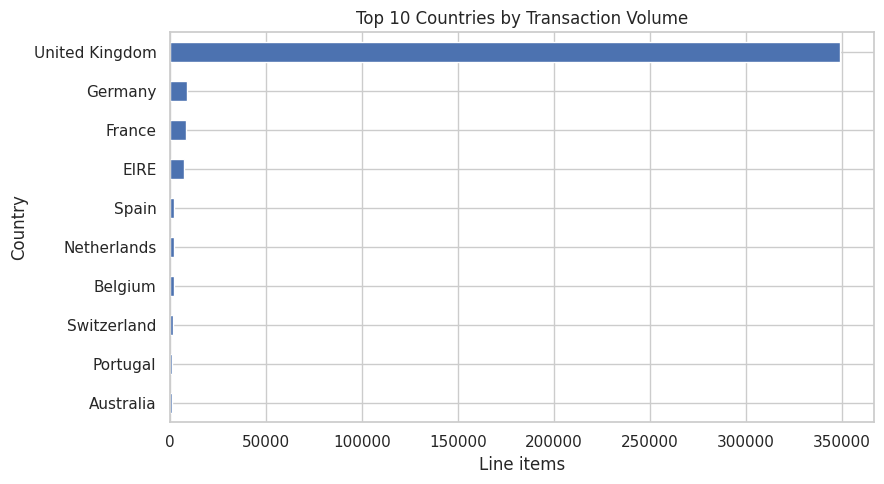

In [5]:
# Transaction volume by country (top 10)
top_countries = df['Country'].value_counts().head(10)
plt.figure(figsize=(9,5))
top_countries.iloc[::-1].plot(kind='barh', color='#4C72B0')
plt.title('Top 10 Countries by Transaction Volume'); plt.xlabel('Line items')
plt.tight_layout(); plt.show()

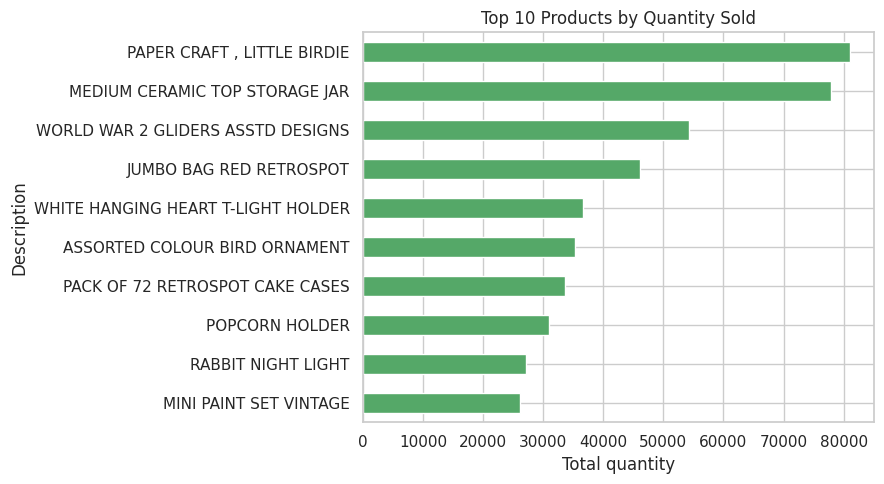

In [6]:
# Top-selling products by quantity
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(9,5))
top_products.iloc[::-1].plot(kind='barh', color='#55A868')
plt.title('Top 10 Products by Quantity Sold'); plt.xlabel('Total quantity')
plt.tight_layout(); plt.show()

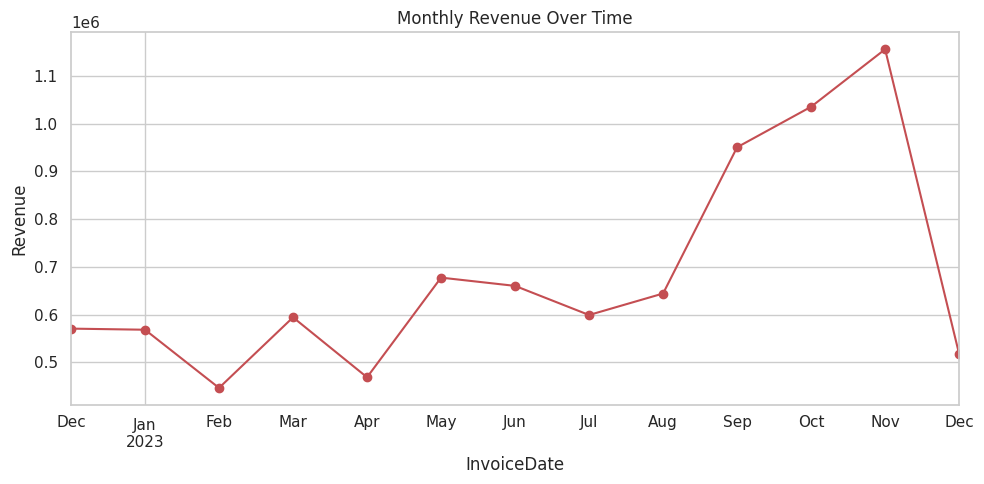

In [7]:
# Revenue trend over time (monthly)
monthly = df.set_index('InvoiceDate')['TotalPrice'].resample('ME').sum()
plt.figure(figsize=(10,5))
monthly.plot(marker='o', color='#C44E52')
plt.title('Monthly Revenue Over Time'); plt.ylabel('Revenue')
plt.tight_layout(); plt.show()

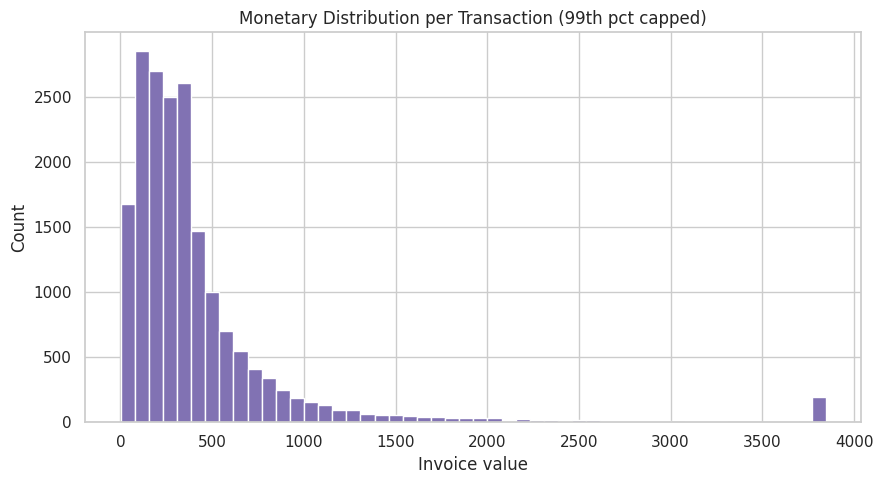

In [8]:
# Monetary distribution per transaction
invoice_value = df.groupby('InvoiceNo')['TotalPrice'].sum()
plt.figure(figsize=(9,5))
plt.hist(invoice_value.clip(upper=invoice_value.quantile(0.99)), bins=50, color='#8172B3')
plt.title('Monetary Distribution per Transaction (99th pct capped)')
plt.xlabel('Invoice value'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

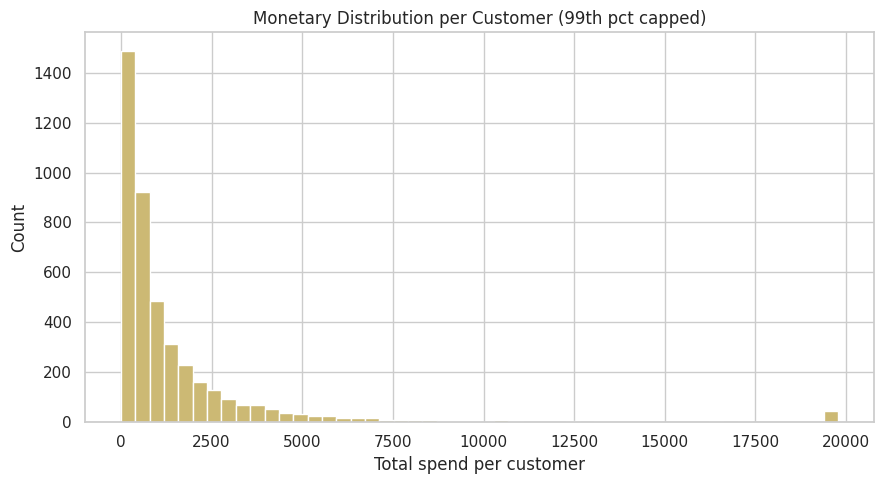

In [9]:
# Monetary distribution per customer
customer_value = df.groupby('CustomerID')['TotalPrice'].sum()
plt.figure(figsize=(9,5))
plt.hist(customer_value.clip(upper=customer_value.quantile(0.99)), bins=50, color='#CCB974')
plt.title('Monetary Distribution per Customer (99th pct capped)')
plt.xlabel('Total spend per customer'); plt.ylabel('Count')
plt.tight_layout(); plt.show()

## 3. RFM Feature Engineering

- **Recency** = days between the reference date (last date in data + 1) and the customer's last purchase
- **Frequency** = number of distinct invoices per customer
- **Monetary** = total amount spent by the customer


In [10]:
from rfm import build_rfm
rfm = build_rfm(df)
print('RFM shape:', rfm.shape)
rfm.describe()

RFM shape: (4338, 4)


,CustomerID,Recency,Frequency,Monetary
count,"4,338.00","4,338.00","4,338.00","4,338.00"
mean,"15,300.41",92.54,4.27,"2,048.69"
std,"1,721.81",100.01,7.70,"8,985.23"
min,"12,346.00",1.00,1.00,3.75
25%,"13,813.25",18.00,1.00,306.48
50%,"15,299.50",51.00,2.00,668.57
75%,"16,778.75",142.00,5.00,"1,660.60"
max,"18,287.00",374.00,209.00,"280,206.02"


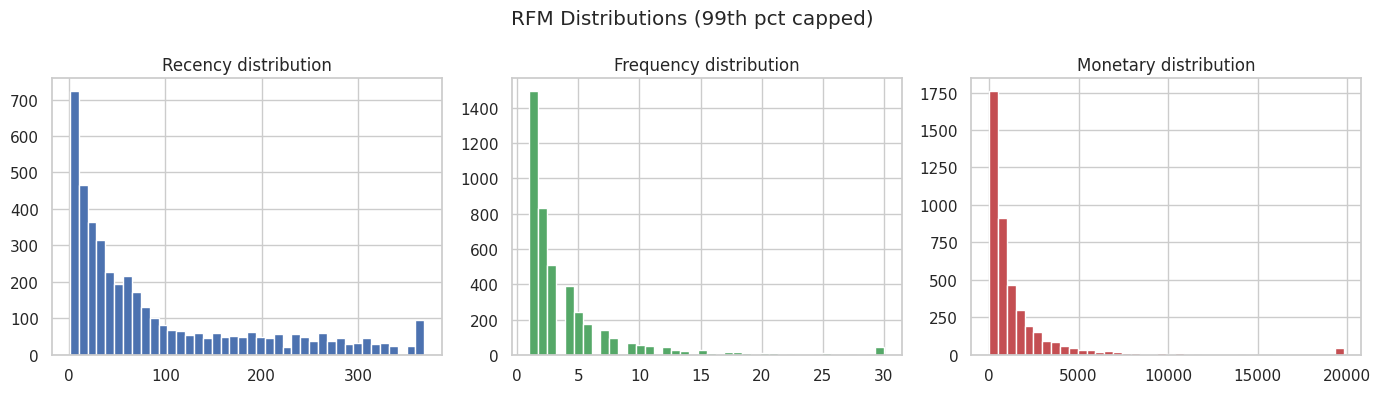

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col, color in zip(axes, ['Recency','Frequency','Monetary'], ['#4C72B0','#55A868','#C44E52']):
    ax.hist(rfm[col].clip(upper=rfm[col].quantile(0.99)), bins=40, color=color)
    ax.set_title(f'{col} distribution')
plt.suptitle('RFM Distributions (99th pct capped)'); plt.tight_layout(); plt.show()

## 4. Choosing the Number of Clusters

Frequency and Monetary are heavily right-skewed, so we **log-transform** them
before standardizing. Without this, KMeans isolates a tiny outlier cluster.
We evaluate `k` from 2 to 10 using inertia (elbow) and silhouette score.


In [12]:
from clustering import scale_rfm, evaluate_k, fit_kmeans, label_segments

scaled, scaler = scale_rfm(rfm)
metrics = evaluate_k(scaled, range(2, 11))
metrics

,k,inertia,silhouette
0,2,"6,874.93",0.41
1,3,"4,299.07",0.42
2,4,"3,243.03",0.38
3,5,"2,760.79",0.34
4,6,"2,396.85",0.33
5,7,"2,166.96",0.30
6,8,"1,961.09",0.30
7,9,"1,819.16",0.28
8,10,"1,687.78",0.28


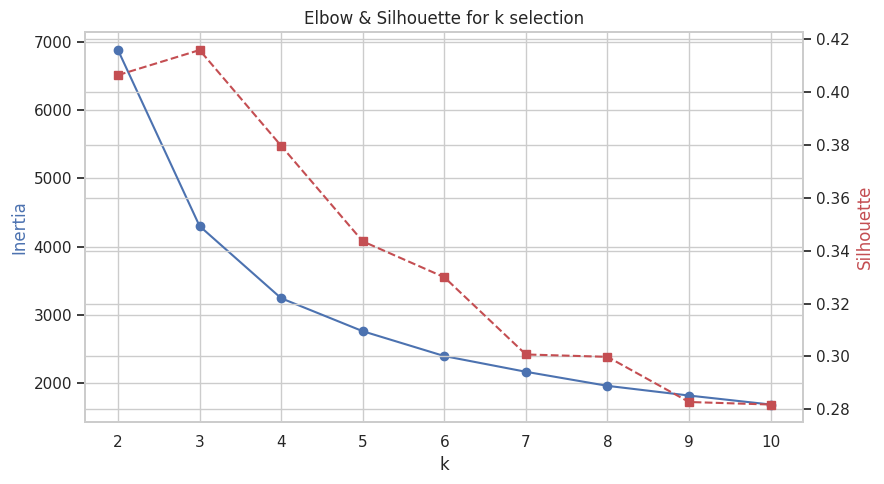

In [13]:
fig, ax1 = plt.subplots(figsize=(9,5))
ax1.plot(metrics['k'], metrics['inertia'], 'o-', color='#4C72B0', label='Inertia')
ax1.set_xlabel('k'); ax1.set_ylabel('Inertia', color='#4C72B0')
ax2 = ax1.twinx()
ax2.plot(metrics['k'], metrics['silhouette'], 's--', color='#C44E52', label='Silhouette')
ax2.set_ylabel('Silhouette', color='#C44E52')
plt.title('Elbow & Silhouette for k selection'); plt.tight_layout(); plt.show()

## 5. KMeans Clustering & Segment Labeling

The brief defines four business segments, so we use **k = 4**. Each cluster is
labeled by ranking its mean RFM values: low recency + high frequency + high
monetary = the best customers.

| Cluster pattern | Segment label |
|---|---|
| High R, High F, High M | **High-Value** |
| Medium F, Medium M | **Regular** |
| Low F, Low M | **Occasional** |
| Long-ago R, Low F, Low M | **At-Risk** |


In [14]:
K = 4
km = fit_kmeans(scaled, K)
rfm['Cluster'] = km.labels_
label_map = label_segments(rfm, 'Cluster')
rfm['Segment'] = rfm['Cluster'].map(label_map)

from sklearn.metrics import silhouette_score
print('Silhouette score @ k=4:', round(silhouette_score(scaled, km.labels_), 3))
print('Inertia:', round(km.inertia_, 1))
label_map

Silhouette score @ k=4: 0.38
Inertia: 3243.0


{2: 'High-Value', 3: 'Regular', 0: 'Occasional', 1: 'At-Risk'}

In [15]:
profile = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean().round(1)
profile['Customers'] = rfm['Segment'].value_counts()
profile

,Recency,Frequency,Monetary,Customers
Segment,,,,
At-Risk,259.40,1.40,385.40,938
High-Value,19.80,15.80,"9,823.40",571
Occasional,58.00,1.50,384.20,1377
Regular,46.10,4.20,"1,644.30",1452


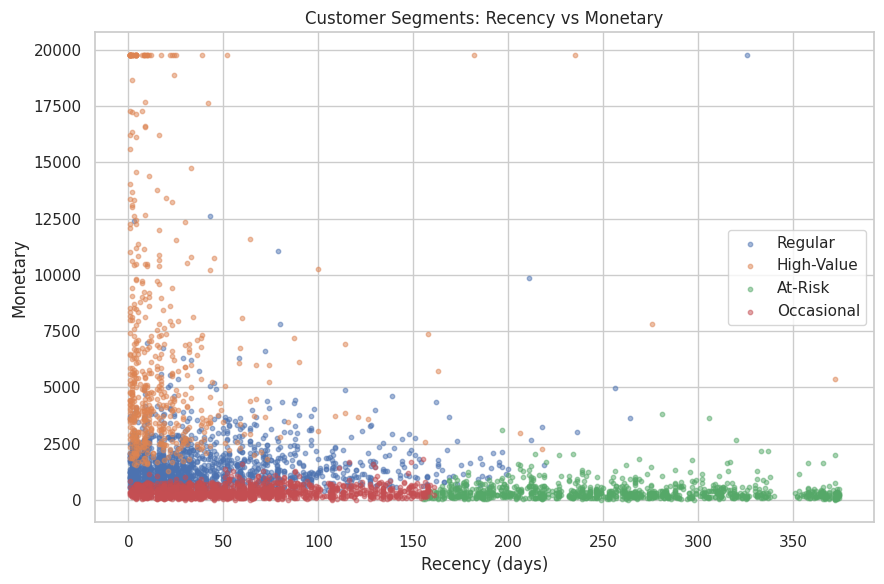

In [16]:
# Cluster scatter: Recency vs Monetary
plt.figure(figsize=(9,6))
for seg in rfm['Segment'].unique():
    sub = rfm[rfm['Segment'] == seg]
    plt.scatter(sub['Recency'], sub['Monetary'].clip(upper=rfm['Monetary'].quantile(0.99)),
                s=10, alpha=0.5, label=seg)
plt.xlabel('Recency (days)'); plt.ylabel('Monetary')
plt.title('Customer Segments: Recency vs Monetary'); plt.legend()
plt.tight_layout(); plt.show()

## 6. Item-Based Collaborative Filtering

We build a Customer × Product matrix of quantities, then compute **cosine
similarity** between products. Given a product, we return the 5 most similar.


In [17]:
from recommender import build_similarity, recommend

sim_df, code2name, name2code = build_similarity(df, min_customers=5)
print('Similarity matrix:', sim_df.shape)

Similarity matrix: (3152, 3152)


In [18]:
# Example: recommend products similar to a known item
example = code2name[sim_df.index[0]]
print('Recommendations for:', example)
recommend(example, sim_df, code2name, name2code, n=5)

Recommendations for: INFLATABLE POLITICAL GLOBE


[{'stock_code': '10125', 'product': 'MINI FUNKY DESIGN TAPES', 'score': 0.854},
 {'stock_code': '23224',
  'product': 'CHERUB HEART DECORATION GOLD',
  'score': 0.713},
 {'stock_code': '23222',
  'product': 'CHRISTMAS TREE HANGING GOLD',
  'score': 0.699},
 {'stock_code': '85014A',
  'product': 'BLACK/BLUE POLKADOT UMBRELLA',
  'score': 0.626},
 {'stock_code': '20682',
  'product': 'RED RETROSPOT CHILDRENS UMBRELLA',
  'score': 0.597}]

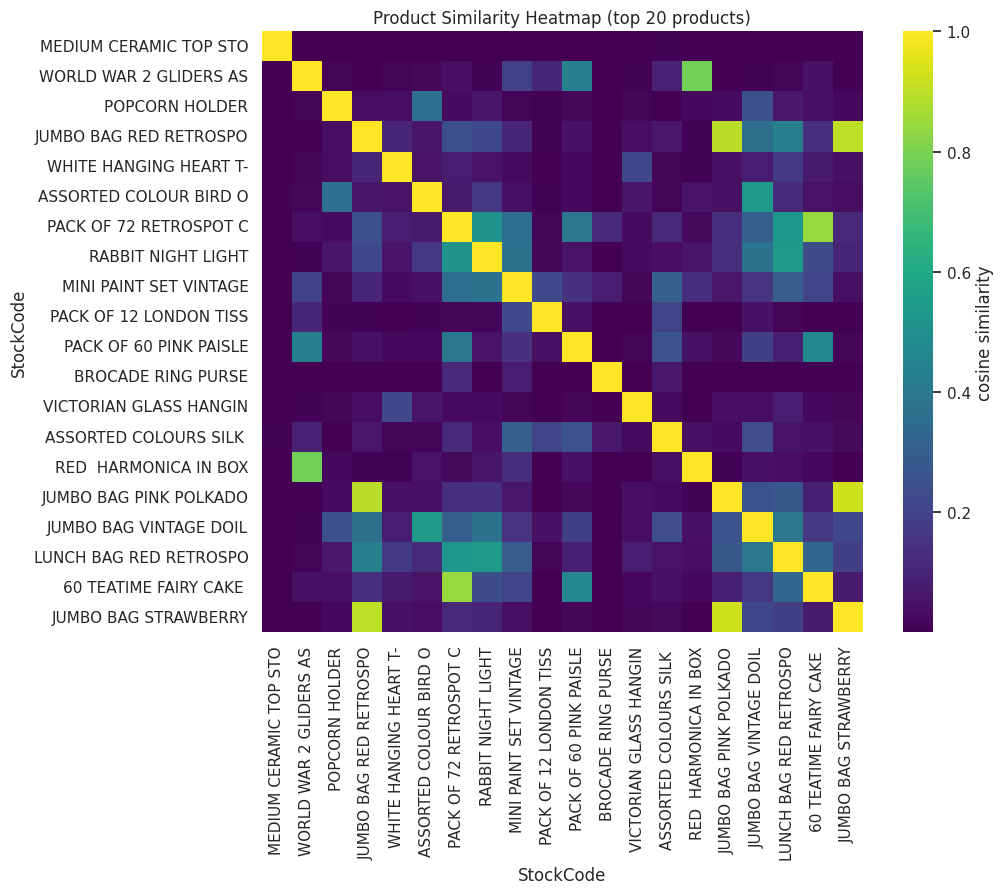

In [19]:
# Product similarity heatmap for the top 20 best-selling products
top_codes = df.groupby('StockCode')['Quantity'].sum().sort_values(ascending=False).index
top_codes = [c for c in top_codes if c in sim_df.index][:20]
heat = sim_df.loc[top_codes, top_codes]
labels = [str(code2name.get(c, c))[:22] for c in top_codes]
plt.figure(figsize=(11,9))
sns.heatmap(heat, xticklabels=labels, yticklabels=labels, cmap='viridis',
            square=True, cbar_kws={'label':'cosine similarity'})
plt.title('Product Similarity Heatmap (top 20 products)')
plt.tight_layout(); plt.show()

## 7. Save Artifacts for the Streamlit App

The full pipeline (including saving a compact recommender) lives in
`src/train_pipeline.py`. Run it from the project root:

```bash
python src/train_pipeline.py
```

Then launch the app:

```bash
streamlit run app/app.py
```


In [20]:
# You can also save directly from here:
import joblib
from recommender import build_top_neighbors

os.makedirs(os.path.join('..','models'), exist_ok=True)
joblib.dump(km, os.path.join('..','models','kmeans_model.pkl'))
joblib.dump(scaler, os.path.join('..','models','scaler.pkl'))
joblib.dump(label_map, os.path.join('..','models','segment_labels.pkl'))
neighbors = build_top_neighbors(sim_df, code2name, top_n=20)
joblib.dump({'neighbors': neighbors, 'code2name': code2name, 'name2code': name2code},
            os.path.join('..','models','recommender.pkl'))
print('Artifacts saved.')

Artifacts saved.


## Summary

- Cleaned ~540K transactions down to ~393K valid rows across 4,338 customers.
- Engineered RFM features and segmented customers into 4 actionable groups:
  **High-Value, Regular, Occasional, At-Risk**.
- Built an item-based collaborative filtering recommender using cosine similarity.
- Saved all models for a real-time Streamlit app with recommendation and
  segmentation modules.
